# Part A – Image Feature Extraction and Classification

## Objective

In this part, asphalt crack and non-crack images are converted into numerical features and classified using traditional machine-learning models.

The workflow is:

**Raw Images → Resize → Grayscale → Feature Extraction → Train/Test Split → ML Models → Evaluation**

The assignment requires intensity-based features and Canny edge-based features. CNNs, deep-learning models and pretrained image embeddings are not used.

## 1. Import Libraries

We use:

- **OpenCV** for reading, resizing, grayscale conversion and Canny edge detection.
- **NumPy** for numerical feature extraction.
- **Pandas** for storing the extracted feature table.
- **Scikit-learn** for splitting data, scaling features and training traditional classifiers.
- **Matplotlib** for visual inspection.

In [1]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 2. Dataset Paths

The dataset is expected to have two folders:

- `Images/Cracks` → label **1**
- `Images/NonCracks` → label **0**

All images are resized to the same dimensions before features are calculated.

In [2]:
CRACK_DIR = "Images/Cracks"
NONCRACK_DIR = "Images/NonCracks"

IMAGE_SIZE = (224, 224)

print("Crack folder:", CRACK_DIR)
print("Non-crack folder:", NONCRACK_DIR)
print("Common image size:", IMAGE_SIZE)

Crack folder: Images/Cracks
Non-crack folder: Images/NonCracks
Common image size: (224, 224)


## 3. Inspect Image Dimensions and Channels

Before feature extraction, one sample image is inspected.

OpenCV normally reads a colour image as a three-channel **BGR** image. We then convert it to a single-channel grayscale image.

Checking dimensions and channels is important because the original images may not all have the same resolution or format.

In [3]:
sample_files = [
    f for f in os.listdir(CRACK_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

sample_path = os.path.join(CRACK_DIR, sample_files[0])
sample_image = cv2.imread(sample_path)

print("Sample image:", sample_files[0])
print("Original shape:", sample_image.shape)
print("Number of dimensions:", sample_image.ndim)

if sample_image.ndim == 3:
    print("Channels:", sample_image.shape[2])

Sample image: IMG_20180513_164959951_HDR resized_448.jpg
Original shape: (448, 448, 3)
Number of dimensions: 3
Channels: 3


## 4. Resize and Convert to Grayscale

A common image size makes the feature extraction process consistent.

Grayscale is used because the required features are based mainly on pixel intensity. It also reduces the representation from three colour channels to one intensity channel.

Resized colour shape: (224, 224, 3)
Grayscale shape: (224, 224)


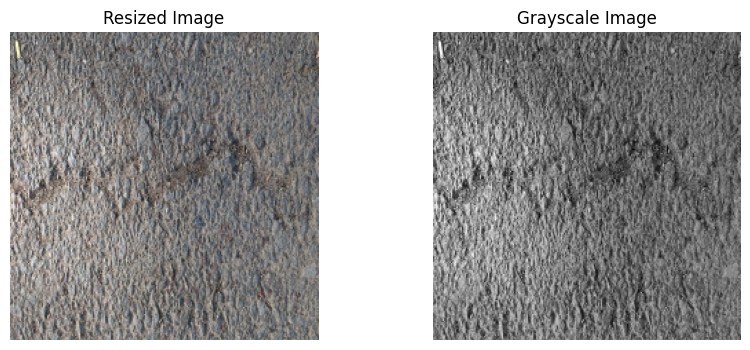

In [4]:
resized_sample = cv2.resize(sample_image, IMAGE_SIZE)
gray_sample = cv2.cvtColor(resized_sample, cv2.COLOR_BGR2GRAY)

print("Resized colour shape:", resized_sample.shape)
print("Grayscale shape:", gray_sample.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(resized_sample, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_sample, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

## 5. Canny Edge Detection

Canny edge detection identifies strong intensity changes in an image.

For crack detection, edges can be useful because cracks often appear as thin structures with intensity changes.

We calculate:

- **Edge count** – number of detected edge pixels.
- **Edge density** – edge count divided by the total number of pixels.

The original representation uses Canny thresholds **50 and 150**.

Edge count: 18520
Edge density: 0.36910076530612246


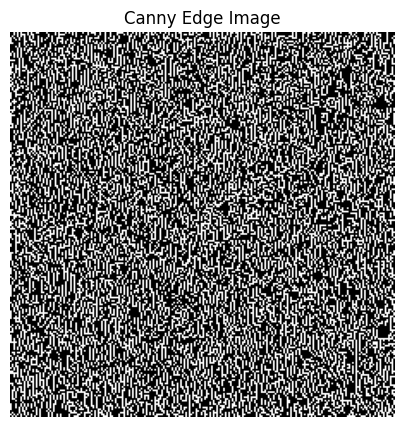

In [5]:
edges = cv2.Canny(gray_sample, 50, 150)

edge_count = np.sum(edges > 0)
edge_density = edge_count / edges.size

print("Edge count:", edge_count)
print("Edge density:", edge_density)

plt.figure(figsize=(5, 5))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")
plt.show()

## 6. Feature Extraction Function

For each image, the following numerical features are extracted:

### Intensity features
- Mean brightness
- Contrast (standard deviation)
- Dark-pixel ratio
- Bright-pixel ratio
- Minimum intensity
- Maximum intensity
- Median intensity

### Edge features
- Edge count
- Edge density

These features convert each image into one numerical feature row that can be given to a traditional ML classifier.

In [6]:
def extract_image_features(
    image_path,
    image_size=(224, 224),
    dark_threshold=50,
    bright_threshold=200,
    canny_low=50,
    canny_high=150
):
    image = cv2.imread(image_path)

    if image is None:
        return None

    image = cv2.resize(image, image_size)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_float = gray.astype(np.float32)

    mean_brightness = np.mean(gray_float)
    contrast = np.std(gray_float)

    dark_ratio = np.mean(gray < dark_threshold)
    bright_ratio = np.mean(gray > bright_threshold)

    min_intensity = np.min(gray_float)
    max_intensity = np.max(gray_float)
    median_intensity = np.median(gray_float)

    edges = cv2.Canny(gray, canny_low, canny_high)
    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_ratio": dark_ratio,
        "bright_ratio": bright_ratio,
        "min_intensity": min_intensity,
        "max_intensity": max_intensity,
        "median_intensity": median_intensity,
        "edge_count": edge_count,
        "edge_density": edge_density
    }

## 7. Extract Features from All Images

Each image is processed independently.

The `label` column is:

- `1` for Crack
- `0` for NonCrack

The resulting DataFrame contains one row per image.

In [7]:
data = []

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

for filename in os.listdir(CRACK_DIR):
    if filename.lower().endswith(valid_extensions):
        path = os.path.join(CRACK_DIR, filename)
        features = extract_image_features(path)

        if features is not None:
            features["filename"] = filename
            features["label"] = 1
            features["class"] = "Crack"
            data.append(features)

for filename in os.listdir(NONCRACK_DIR):
    if filename.lower().endswith(valid_extensions):
        path = os.path.join(NONCRACK_DIR, filename)
        features = extract_image_features(path)

        if features is not None:
            features["filename"] = filename
            features["label"] = 0
            features["class"] = "NonCrack"
            data.append(features)

image_df = pd.DataFrame(data)

print("Feature table shape:", image_df.shape)
display(image_df.head())

Feature table shape: (400, 12)


,mean_brightness,contrast,dark_ratio,bright_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density,filename,label,class
0,122.224609,31.513481,0.003846,0.010922,23.0,247.0,121.0,18520,0.369101,IMG_20180513_164959951_HDR resized_448.jpg,1,Crack
1,131.948685,24.096115,0.002790,0.003787,8.0,251.0,133.0,18094,0.360611,IMG_20180513_165129852_HDR resized_448.jpg,1,Crack
2,121.297310,29.884272,0.013333,0.008171,2.0,241.0,121.0,17454,0.347856,IMG_20180513_165150613_HDR resized_448.jpg,1,Crack
3,130.245590,25.649017,0.001893,0.004006,20.0,253.0,131.0,18767,0.374023,IMG_20180513_165345878_HDR resized_448.jpg,1,Crack
4,131.208878,26.237600,0.002372,0.006258,11.0,254.0,132.0,18349,0.365693,IMG_20180513_165349788_HDR resized_448.jpg,1,Crack


## 8. Check Class Distribution and Extracted Features

The class distribution is checked to make sure both classes are represented.

The feature table is also saved as a CSV file so that the extracted numerical representation can be inspected or included in the project repository.

In [8]:
print("Class distribution:")
print(image_df["class"].value_counts())

feature_columns = [
    "mean_brightness",
    "contrast",
    "dark_ratio",
    "bright_ratio",
    "min_intensity",
    "max_intensity",
    "median_intensity",
    "edge_count",
    "edge_density"
]

display(image_df[feature_columns + ["label"]].head())

image_df.to_csv("image_features.csv", index=False)
print("Saved: image_features.csv")

Class distribution:
class
Crack       200
NonCrack    200
Name: count, dtype: int64


,mean_brightness,contrast,dark_ratio,bright_ratio,min_intensity,max_intensity,median_intensity,edge_count,edge_density,label
0,122.224609,31.513481,0.003846,0.010922,23.0,247.0,121.0,18520,0.369101,1
1,131.948685,24.096115,0.002790,0.003787,8.0,251.0,133.0,18094,0.360611,1
2,121.297310,29.884272,0.013333,0.008171,2.0,241.0,121.0,17454,0.347856,1
3,130.245590,25.649017,0.001893,0.004006,20.0,253.0,131.0,18767,0.374023,1
4,131.208878,26.237600,0.002372,0.006258,11.0,254.0,132.0,18349,0.365693,1


Saved: image_features.csv


## 9. Prepare X and y

`X` contains the numerical image features.

`y` contains the target class.

A stratified train-test split is used so that the proportion of crack and non-crack images is maintained in both sets.

In [9]:
X = image_df[feature_columns]
y = image_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (320, 9)
Testing shape: (80, 9)


## 10. Model Selection

Two traditional classifiers are used:

### Logistic Regression
Logistic Regression is a simple and interpretable baseline for binary classification. It works well when the classes can be separated using combinations of numerical features.

### Random Forest
Random Forest is a tree-based ensemble model. It can capture non-linear relationships between intensity/edge features and the crack label.

For Logistic Regression, `StandardScaler` is used because the extracted features have different numerical scales. Random Forest does not require feature scaling.

In [10]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

## 11. Train and Evaluate the Models

The assignment requires:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Training time
- Prediction time

The same train-test split is used for both models so their results can be compared fairly.

In [11]:
results = []
confusion_matrices = {}

for model_name, model in models.items():

    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_prediction = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_prediction

    results.append({
        "Model": model_name,
        "Features": X_train.shape[1],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "Training Time": train_time,
        "Prediction Time": prediction_time
    })

    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)

results_df = pd.DataFrame(results)
display(results_df)

,Model,Features,Accuracy,Precision,Recall,F1-score,Training Time,Prediction Time
0,Logistic Regression,9,0.9375,0.926829,0.95,0.938272,0.020294,0.003006
1,Random Forest,9,0.9500,0.950000,0.95,0.950000,1.185512,0.032505


## 12. Confusion Matrices

A confusion matrix shows the number of:

- True Negatives
- False Positives
- False Negatives
- True Positives

This is useful because accuracy alone does not show which class is being misclassified.

In [12]:
for model_name, cm in confusion_matrices.items():
    print(model_name)
    print(cm)
    print()

Logistic Regression
[[37  3]
 [ 2 38]]

Random Forest
[[38  2]
 [ 2 38]]



## 13. Classification Reports

The classification report gives precision, recall and F1-score for each class.

For crack detection, recall is especially useful because it measures how many actual crack images are successfully detected.

In [13]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["NonCrack", "Crack"],
        zero_division=0
    ))

Logistic Regression
              precision    recall  f1-score   support

    NonCrack       0.95      0.93      0.94        40
       Crack       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80

Random Forest
              precision    recall  f1-score   support

    NonCrack       0.95      0.95      0.95        40
       Crack       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



## 14. Part A Conclusion

The images were converted into a compact numerical representation using intensity statistics and Canny edge features.

Two traditional classifiers were evaluated using the same train-test split. The final results table compares predictive performance and computational cost.

The model with the most suitable result should be discussed using the actual values obtained from the experiment rather than assuming in advance which classifier will perform best.